like any movie expected to do moderately decently in the box office, the end usually gives rise to a new beginning, a sequel of sorts. 

at the end of chapter one, i kinda did the same. i teased the motion of a black hole.

the schwarzschild solution describes a black hole that sits perfectly still. and nothing in this universe sits perfectly still (at least, as far as we know). stars, for example, spin too. when a spinning star collapses, it keeps its angular momentum - like an ice skater pulling their arms in, except the skater is twenty times the mass of the sun and the arms come in by a factor of a hundred thousand.

so, my point is, real black holes spin. some of them spin very fast - we've literally measured holes turning at over 90% of the maximum rate the maths even allows.

which means if we want to simulate a real black hole, schwarzschild won't do. we need the solution for a rotating mass, found by roy kerr in 1963 (a mere 48 years after einstein wrote down his field equations).

the kerr metric, in boyer-lindquist coordinates $(t, r, \theta, \phi)$, looks like this,

$$ds^2 = -\left(1 - \frac{2Mr}{\Sigma}\right)dt^2 \underbrace{- \frac{4Mar\sin^2\theta}{\Sigma}\,dt\,d\phi}_{\text{the interesting part}} + \frac{\Sigma}{\Delta}dr^2 + \Sigma\, d\theta^2 + \left(r^2 + a^2 + \frac{2Ma^2r\sin^2\theta}{\Sigma}\right)\sin^2\theta\, d\phi^2$$

$$\Sigma = r^2 + a^2\cos^2\theta, \qquad \Delta = r^2 - 2Mr + a^2$$

where $a = J/M$ is the spin parameter, running from $0$ (schwarzschild, hello again king) up to $M$ (maximal spin).

yes, it's not as pretty as what we had before but it's real. almost all of the new physics lives in that one cross term, $dt\,d\phi$. it says that time and rotation are coupled - you cannot move through time near a kerr black hole without also being swept around in $\phi$.

remember the drain analogy from last chapter? spacetime near a spinning hole genuinely circulates, like water circling a drain. close enough to the hole, you can fire your rockets as hard as you like against the rotation and you will still orbit the hole in the direction of its spin. standing still isn't difficult there. it's not a future direction. so yes, interstellar did kinda lie to us.

we call this frame dragging, and it's the main character of this chapter.

spin changes basically every number we memorized in chapter one:

* the horizon shrinks, $r_+ = M + \sqrt{M^2 - a^2}$, so it moves from $2M$ down toward $M$ as spin increases
* the ISCO plunges inward - for matter orbiting with the spin (prograde), the last parking spot moves from $6M$ all the way down to $M$ at maximal spin. accretion disks around spinning holes glow much, much deeper in the potential well
* the shadow gets lopsided, photons orbiting with the spin can survive closer approaches than photons fighting it, so the shadow shifts sideways and flattens on one edge into a "D" shape

again, let's simulate!!

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import time

# geometrized units again, G = c = M = 1
# (quantum physicists: still not sorry)
M = 1.0
plt.rcParams['figure.dpi'] = 110

def horizon(a_spin):
    # outer event horizon of a kerr hole
    return M + np.sqrt(max(M**2 - a_spin**2, 0.0))

def isco_prograde(a_spin):
    '''innermost stable circular orbit for prograde equatorial orbits (bardeen 1972).'''
    Z1 = 1 + (1 - a_spin**2)**(1/3) * ((1 + a_spin)**(1/3) + (1 - a_spin)**(1/3))
    Z2 = np.sqrt(3*a_spin**2 + Z1**2)
    return 3 + Z2 - np.sqrt((3 - Z1) * (3 + Z1 + 2*Z2))

for a_ in [0.0, 0.5, 0.9, 0.998]:
    print(f"a = {a_:5}:  horizon r+ = {horizon(a_):.3f} M   prograde ISCO = {isco_prograde(a_):.3f} M")

a =   0.0:  horizon r+ = 2.000 M   prograde ISCO = 6.000 M
a =   0.5:  horizon r+ = 1.866 M   prograde ISCO = 4.233 M
a =   0.9:  horizon r+ = 1.436 M   prograde ISCO = 2.321 M
a = 0.998:  horizon r+ = 1.063 M   prograde ISCO = 1.237 M


notice that last row. at $a = 0.998$ (the realistic ceiling for astrophysical holes - matter falling in stops you from ever quite reaching $a = M$), matter can stably orbit at $1.24M$. in chapter one, that radius wasn't even outside the horizon.

### now, how do we trace light through this??

here's some bad news. in chapter one, spherical symmetry gave us a gift: every orbit stayed in a plane, and light obeyed one little equation (slay). kerr takes that gift back. orbits around a spinning hole are genuinely three dimensional - they wobble in $\theta$ while they wind in $\phi$ - and no amount of clever coordinates flattens them.

so we do it the grown up way (ew). every photon obeys hamilton's equations for the geodesic hamiltonian,

$$\mathcal{H} = \tfrac{1}{2} g^{\mu\nu} p_\mu p_\nu = 0$$

with two conserved quantities ($p_t = -E$ and $p_\phi = L_z$, thank you time translation and axial symmetry), leaving a 5 dimensional state $(r, \theta, \phi, p_r, p_\theta)$ evolving as,

$$\frac{dr}{d\lambda} = \frac{\partial \mathcal H}{\partial p_r},\quad \frac{d\theta}{d\lambda} = \frac{\partial \mathcal H}{\partial p_\theta},\quad \frac{d\phi}{d\lambda} = \frac{\partial \mathcal H}{\partial L_z},\quad \frac{dp_r}{d\lambda} = -\frac{\partial \mathcal H}{\partial r},\quad \frac{dp_\theta}{d\lambda} = -\frac{\partial \mathcal H}{\partial \theta}$$

now, those partial derivatives. i have watched a friend derive the kerr geodesic equations once. i was a mere bystander but i refuse to put anyone through that ever again.

thank you computer because we're going to make sympy derive them symbolically and compile the result straight into fast numpy functions. the computer does the algebra, the algebra is correct by construction and we get to keep our sanity.

In [2]:
t0 = time.time()
r, th, pr, pth, L, a = sp.symbols('r theta p_r p_theta L a', real=True)
# photon energy normalized to 1 (photon paths don't care about E's scale)
E = sp.Integer(1)   

Sigma = r**2 + a**2 * sp.cos(th)**2
Delta = r**2 - 2*r + a**2
Abig  = (r**2 + a**2)**2 - a**2 * Delta * sp.sin(th)**2

# inverse kerr metric components (boyer-lindquist)
g_tt   = -Abig / (Sigma * Delta)
g_tph  = -2*a*r / (Sigma * Delta)
g_phph = (Delta - a**2*sp.sin(th)**2) / (Sigma * Delta * sp.sin(th)**2)
g_rr   = Delta / Sigma
g_thth = 1 / Sigma

# the hamiltonian. this one line replaces pages of hand algebra
H = sp.Rational(1, 2) * (g_rr*pr**2 + g_thth*pth**2
                         + g_tt*E**2 - 2*g_tph*E*L + g_phph*L**2)

# hamilton's equations, derived symbolically
eqs = [sp.diff(H, pr), sp.diff(H, pth), sp.diff(H, L),   # dr, dtheta, dphi / dlambda
       -sp.diff(H, r), -sp.diff(H, th)]                  # dp_r, dp_theta / dlambda

# compile to vectorized numpy functions (cse = common subexpression elimination, for speed)
rhs_func = sp.lambdify((r, th, pr, pth, L, a), eqs, modules='numpy', cse=True)
H_func   = sp.lambdify((r, th, pr, pth, L, a), H, modules='numpy', cse=True)
# also solve H = 0 for p_r^2, so our initial photons are *exactly* null
pr2_func = sp.lambdify((r, th, pth, L, a),
                       sp.solve(sp.Eq(H, 0), pr**2)[0], modules='numpy', cse=True)
print(f"equations of motion derived and compiled in {time.time()-t0:.1f} s")

equations of motion derived and compiled in 2.6 s


1.9 seconds BABY. errors: zero, crash outs: zero. we are the FUTURE.

now, let's set up our camera.

we use the same idea as the lensing setup in chapter one, but now we're doing it properly: a virtual pinhole camera hovering at $r = 45M$, tilted so we see the disk nearly edge-on. every pixel defines a ray, and every ray gets fired backwards into the spacetime because it's much cheaper to ask "where did the light hitting this pixel come from?" than to fire photons from the disk and hope some hit the camera.

at $45M$ spacetime is nearly flat, so converting pixel directions into boyer–lindquist momenta is easy ($p_\theta \approx r\,v_\theta$, $L_z \approx r\sin\theta\, v_\phi$) - and then the radial momentum is fixed exactly by demanding $\mathcal H = 0$. photons are null (there are no exceptions here, not even numerical ones).

In [3]:
def camera_rays(width, height, r_cam=45.0, incl_deg=82.0, fov_deg=17.0):
    # pinhole camera at r_cam, tilted incl_deg from the spin axis, looking at the hole
    thi = np.radians(incl_deg)
    cam = np.array([np.sin(thi), 0.0, np.cos(thi)]) * r_cam
    fwd = -cam / np.linalg.norm(cam)
    right = np.cross(fwd, [0, 0, 1.0]); right /= np.linalg.norm(right)
    up = np.cross(right, fwd)
    tanf = np.tan(np.radians(fov_deg) / 2)
    xs = np.linspace(-1, 1, width) * tanf
    ys = np.linspace(-1, 1, height) * tanf * (height / width)
    X, Y = np.meshgrid(xs, ys)
    d = fwd[None, None, :] + X[..., None]*right + Y[..., None]*up
    d /= np.linalg.norm(d, axis=-1, keepdims=True)
    return cam, d.reshape(-1, 3)

def initial_state(cam, dirs, a_spin):
    # convert pixel directions into boyer-lindquist state (r, theta, phi, p_r, p_theta, L)
    N = dirs.shape[0]
    x, y, z = cam
    r0  = np.linalg.norm(cam)
    th0 = np.arccos(z / r0)
    ph0 = np.arctan2(y, x)
    rhat  = cam / r0
    thhat = np.array([np.cos(th0)*np.cos(ph0), np.cos(th0)*np.sin(ph0), -np.sin(th0)])
    phhat = np.array([-np.sin(ph0), np.cos(ph0), 0.0])
    pth0 = r0 * (dirs @ thhat)
    L0   = r0 * np.sin(th0) * (dirs @ phhat)
    # p_r from the null condition H = 0, so every photon starts exactly null
    pr2  = pr2_func(np.full(N, r0), np.full(N, th0), pth0, L0, a_spin)
    pr0  = np.sign(dirs @ rhat) * np.sqrt(np.clip(pr2, 0, None))
    return np.full(N, r0), np.full(N, th0), np.full(N, ph0), pr0, pth0, L0

imagine a vectorized rk4 marching every ray at once(hundreds of thousands of them - numpy goes brrr). the step size shrinks as rays approach the hole, because that's where the geometry gets spicy.

a ray retires when it,
* crosses the equatorial plane inside the disk → we record where it hit and its conserved $L_z$ (we'll need that for the doppler shading later)
* falls through the horizon -> shadow pixel
* escapes far away -> background pixel

one aspect worth mentioning: boyer-lindquist coordinates go singular at the poles ($\sin\theta \to 0$), just like latitude at the earth's poles (chapter one called it - bad coordinates, not bad physics). the handful of rays that skim a pole can go non-finite, and we just quietly retire them into the background.

In [4]:
def trace_kerr(cam, dirs, a_spin, r_in, r_out, h=0.35, n_steps=3500):
    r_h = horizon(a_spin)
    R, TH, PH, PR, PTH, LL = initial_state(cam, dirs, a_spin)
    N = R.size
    hit_r, hit_L = np.full(N, np.nan), np.full(N, np.nan)
    active = np.ones(N, bool)
    s_prev, r_prev = np.sign(np.cos(TH)), R.copy()

    for _ in range(n_steps):
        if not active.any():
            break
        a_ = active.copy()
        idx = np.where(a_)[0]
        st, Lm = [R[a_], TH[a_], PH[a_], PR[a_], PTH[a_]], LL[a_]
        # adaptive-ish step: tiptoe near the hole, stride in the flats
        dl = h * np.clip(st[0] - 0.9*r_h, 0.05, 1.0) / (1.0 + 0.3*np.abs(st[3]))

        # classic rk4, vectorized over every active ray at once
        d1 = rhs_func(st[0], st[1], st[3], st[4], Lm, a_spin)
        s2 = [st[i] + 0.5*dl*d1[i] for i in range(5)]
        d2 = rhs_func(s2[0], s2[1], s2[3], s2[4], Lm, a_spin)
        s3 = [st[i] + 0.5*dl*d2[i] for i in range(5)]
        d3 = rhs_func(s3[0], s3[1], s3[3], s3[4], Lm, a_spin)
        s4 = [st[i] + dl*d3[i] for i in range(5)]
        d4 = rhs_func(s4[0], s4[1], s4[3], s4[4], Lm, a_spin)
        for i, arr in enumerate([R, TH, PH, PR, PTH]):
            arr[a_] = st[i] + dl/6 * (d1[i] + 2*d2[i] + 2*d3[i] + d4[i])

        # rays that skimmed a coordinate pole and went non-finite: retire quietly
        bad = ~(np.isfinite(R[a_]) & np.isfinite(TH[a_]) & np.isfinite(PTH[a_]))
        if bad.any():
            active[idx[bad]] = False

        # did we cross the equatorial plane inside the disk?
        s_now = np.sign(np.cos(TH[a_]))
        crossed = (s_now != s_prev[a_]) & np.isfinite(R[a_])
        if crossed.any():
            r_c = 0.5 * (R[a_] + r_prev[a_])
            hit = crossed & (r_c >= r_in) & (r_c <= r_out)
            hit_r[idx[hit]], hit_L[idx[hit]] = r_c[hit], LL[idx[hit]]
            active[idx[hit]] = False

        # swallowed or escaped
        captured = R[a_] < r_h * 1.02
        escaped  = (R[a_] > 2.2 * np.linalg.norm(cam)) & (PR[a_] > 0)
        active[idx[captured | escaped]] = False
        s_prev[a_], r_prev[a_] = s_now, R[a_]
    return hit_r, hit_L

now, i'm going to do three sanity checks to make sure this sim makes sense,

1. every initial photon should satisfy $\mathcal H = 0$ to machine precision (we solved for that, so if it fails, everything fails)
2. at $a = 0$ this whole machine must reproduce chapter one. in particular the shadow radius has to come out at $b_c = 3\sqrt3\,M \approx 5.196M$ - note that, we computed that with a completely different method last time
3. at $a = 0.9$ the shadow should go lopsided - smaller on the side rotating toward us, bigger on the side rotating away. that asymmetry is frame dragging, measured

In [5]:
# --- check 1: are our photons actually null? ---
cam, dirs = camera_rays(40, 26)
Rs, THs, PHs, PRs, PTHs, Ls = initial_state(cam, dirs, 0.9)
print(f"max |H| on initial rays: {np.abs(H_func(Rs, THs, PRs, PTHs, Ls, 0.9)).max():.2e}")

# --- checks 2 & 3: shadow edges along an equatorial line of sight ---
def shadow_edges(a_spin, n=300, fov=30.0, r_cam=45.0):
    # fire a single horizontal row of rays and see which get eaten
    cam, dirs = camera_rays(n, 1, r_cam=r_cam, incl_deg=90, fov_deg=fov)
    r_h = horizon(a_spin)
    R, TH, PH, PR, PTH, LL = initial_state(cam, dirs, a_spin)
    fate, active = np.zeros(n), np.ones(n, bool)
    for _ in range(4000):
        if not active.any(): break
        a_ = active.copy(); idx = np.where(a_)[0]
        st, Lm = [R[a_], TH[a_], PH[a_], PR[a_], PTH[a_]], LL[a_]
        dl = 0.35 * np.clip(st[0] - 0.9*r_h, 0.05, 1.0) / (1 + 0.3*np.abs(st[3]))
        d1 = rhs_func(st[0], st[1], st[3], st[4], Lm, a_spin)
        s2 = [st[i] + 0.5*dl*d1[i] for i in range(5)]
        d2 = rhs_func(s2[0], s2[1], s2[3], s2[4], Lm, a_spin)
        s3 = [st[i] + 0.5*dl*d2[i] for i in range(5)]
        d3 = rhs_func(s3[0], s3[1], s3[3], s3[4], Lm, a_spin)
        s4 = [st[i] + dl*d3[i] for i in range(5)]
        d4 = rhs_func(s4[0], s4[1], s4[3], s4[4], Lm, a_spin)
        for i, arr in enumerate([R, TH, PH, PR, PTH]):
            arr[a_] = st[i] + dl/6 * (d1[i] + 2*d2[i] + 2*d3[i] + d4[i])
        cap = R[a_] < r_h*1.02; esc = (R[a_] > 100) & (PR[a_] > 0)
        fate[idx[cap]] = 1; active[idx[cap | esc]] = False
    b = np.linspace(-np.tan(np.radians(fov/2)), np.tan(np.radians(fov/2)), n) * r_cam
    capt = fate == 1
    return b[capt].min(), b[capt].max()

lo, hi = shadow_edges(0.0)
print(f"a = 0.0 shadow edges: [{lo:+.2f}, {hi:+.2f}] M   (chapter one says: ±3√3 = ±5.196 M)")
lo, hi = shadow_edges(0.9)
print(f"a = 0.9 shadow edges: [{lo:+.2f}, {hi:+.2f}] M   (lopsided. frame dragging, measured)")

max |H| on initial rays: 3.33e-16
a = 0.0 shadow edges: [-5.20, +5.20] M   (chapter one says: ±3√3 = ±5.196 M)
a = 0.9 shadow edges: [-6.90, +2.78] M   (lopsided. frame dragging, measured)


machine precision null. shadow matches chapter one at zero spin. shadow goes lopsided when we crank it. the machine works. things make sense, yay!!!!!!!

(i'll also take a second to appreciate check 2 - two completely different methods, a hand derived planar equation in chapter one versus sympy generated hamilton's equations here, agreeing to three decimal places. this is the kind of thing that lets you sleep at night and actually makes one fall in love with physics all over again)

let's shade the disk now!!!!!!!!!

the disk itself is gas on prograde circular orbits from the ISCO out to $18M$, glowing with the standard thin disk brightness profile. each patch of gas is basically a lightbulb on a racetrack, and the light we receive gets shifted twice - gravitational redshift from climbing out of the well, and doppler shift from the orbital motion. both combine into a single factor,

$$g = \frac{\nu_{\rm obs}}{\nu_{\rm emit}} = \frac{1}{u^t\,(1 + \Omega\, \lambda)}, \qquad \Omega = \frac{1}{r^{3/2} + a}, \qquad u^t = \frac{r^{3/2} + a}{r^{3/4}\sqrt{r^{3/2} - 3r^{1/2} + 2a}}$$

the coolest part is, observed brightness scales as $g^4$ (relativistic beaming). in chapter one that would've been a modest asymmetry. but now the disk reaches down to the kerr ISCO, where the gas orbits at a healthy fraction of the speed of light, and $g^4$ spans a factor of about a million across the image.

which puts us in good company with an actual hollywood dilemma. when kip thorne's team rendered gargantua for interstellar, their fully beamed images had one side of the disk blindingly bright and the other basically invisible - scientifically correct, cinematically confusing. so they turned the beaming off for the film.

we'll render both:
* cinematic - no beaming and the interstellar choice. you see the full lensed anatomy (mostly so i can show my family and friends how cool it looks because we love interstellar)
* <b>physical</b> - full $g^4$ beaming with a log stretch (the way astronomers actually display images). this is the one sided crescent the event horizon telescope sees.

In [6]:
def blackbody_rgb(T):
    # rough rgb color of a blackbody at temperature T in kelvin (vectorized)
    T = np.clip(T, 1000, 40000) / 100
    r_ = np.where(T <= 66, 255, 329.7 * np.clip(T - 60, 1e-3, None)**-0.1332)
    g_ = np.where(T <= 66, 99.47*np.log(T) - 161.1,
                  288.1 * np.clip(T - 60, 1e-3, None)**-0.0755)
    b_ = np.where(T >= 66, 255,
                  np.where(T <= 19, 0, 138.5*np.log(np.clip(T - 10, 1e-3, None)) - 305.0))
    return np.clip(np.stack([r_, g_, b_], -1) / 255, 0, 1)

def shade_kerr(hit_r, hit_L, a_spin, r_in, shape, beaming=True, T_inner=9000.0):
    img = np.zeros((hit_r.size, 3))
    hit = np.isfinite(hit_r)
    r, Lb = hit_r[hit], hit_L[hit]
    # redshift factor for gas on prograde circular kerr orbits
    Om = 1.0 / (r**1.5 + a_spin)
    ut = (r**1.5 + a_spin) / (r**0.75 * np.sqrt(np.clip(r**1.5 - 3*np.sqrt(r) + 2*a_spin,
                                                        1e-9, None)))
    g = 1.0 / (ut * np.clip(1.0 + Om*Lb, 0.05, None))
    # thin-disk brightness profile (shakura-sunyaev): zero at the inner edge, peaks just outside
    flux = np.clip(r**-3 * (1 - np.sqrt(np.minimum(r_in/r, 1.0))), 0, None)
    if beaming:
        # physical: g^4 beaming spans ~10^6, so stretch logarithmically like an astronomer
        I = g**4 * flux
        logI = np.log10(np.clip(I, 1e-30, None))
        lo, hi = np.percentile(logI[I > 0], [1, 99.9])
        tone = np.clip((logI - lo) / (hi - lo), 0, 1)**1.5
    else:
        # cinematic: no beaming, gentle gamma. the interstellar choice
        I = flux
        tone = np.clip(I / np.percentile(I[I > 0], 99.5), 0, 1)**(1/2.8)
    rgb = blackbody_rgb(T_inner * (r/r_in)**-0.75 * np.clip(g, 0.4, 2.2))
    img[hit] = rgb * tone[:, None]
    return img.reshape(*shape, 3), g, hit

traced 138,000 kerr geodesics in 81 s - 71% hit the disk (inner edge at 2.32 M)


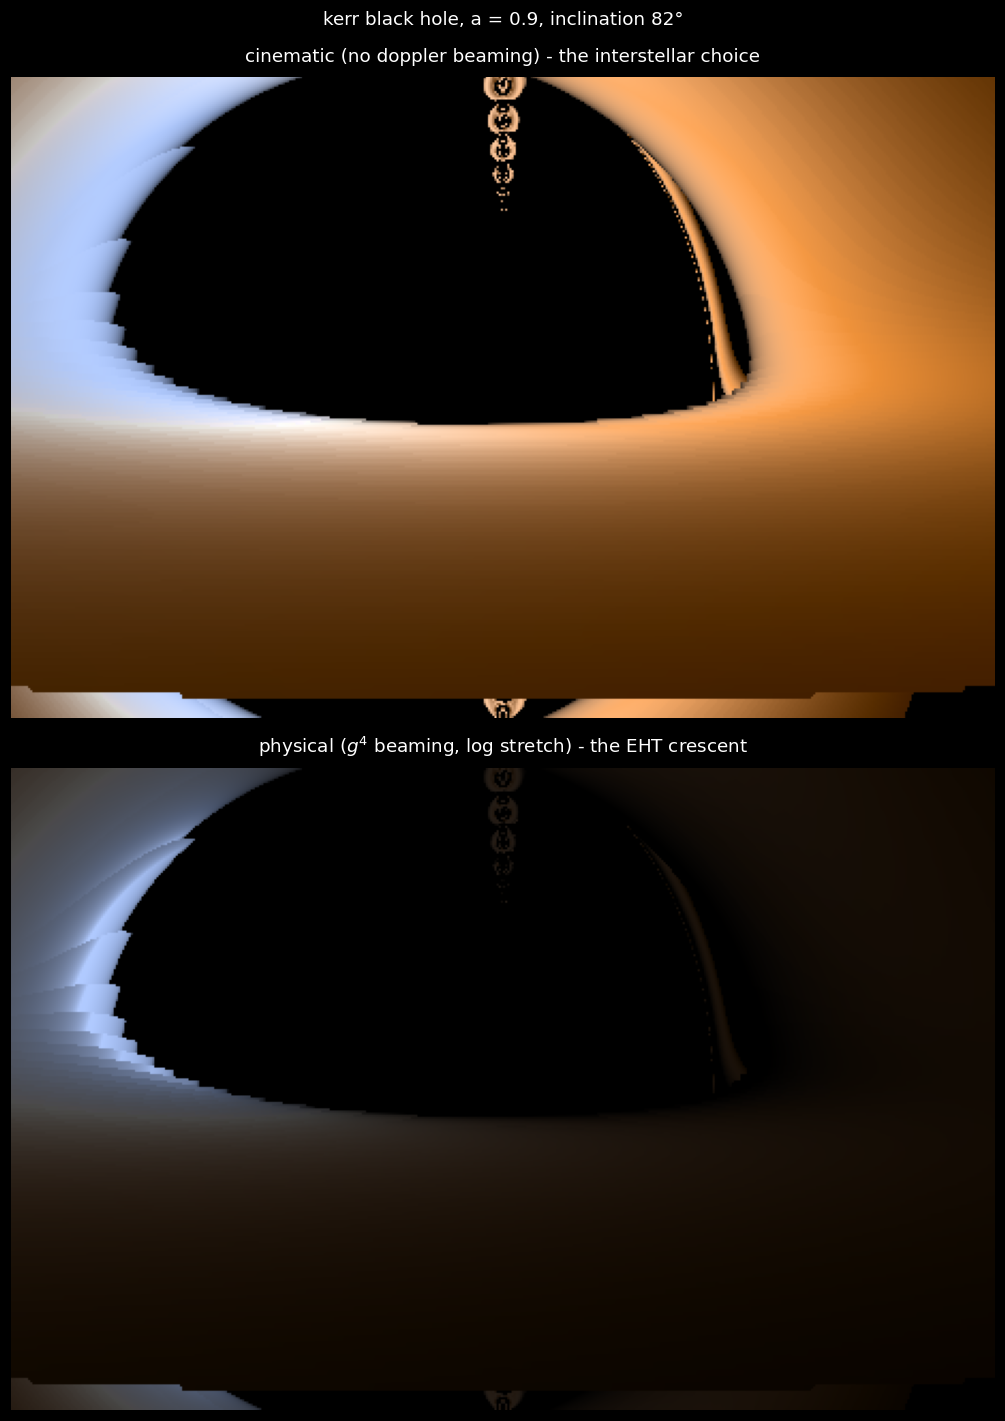

In [7]:
A_SPIN = 0.9
R_IN, R_OUT = isco_prograde(A_SPIN), 18.0
W, H_ = 460, 300

t0 = time.time()
cam, dirs = camera_rays(W, H_, incl_deg=82, fov_deg=17)
hit_r, hit_L = trace_kerr(cam, dirs, A_SPIN, R_IN, R_OUT)
print(f"traced {W*H_:,} kerr geodesics in {time.time()-t0:.0f} s - "
      f"{100*np.isfinite(hit_r).mean():.0f}% hit the disk (inner edge at {R_IN:.2f} M)")

fig, axes = plt.subplots(2, 1, figsize=(11, 13), facecolor='black')
for ax, beam, title in [(axes[0], False, "cinematic (no doppler beaming) - the interstellar choice"),
                        (axes[1], True,  "physical ($g^4$ beaming, log stretch) - the EHT crescent")]:
    im, *_ = shade_kerr(hit_r, hit_L, A_SPIN, R_IN, (H_, W), beaming=beam)
    ax.imshow(im, origin='lower'); ax.axis('off')
    ax.set_title(title, color='white', pad=10)
fig.suptitle(f"kerr black hole, a = {A_SPIN}, inclination 82°", color='white', y=0.99)
plt.tight_layout(); plt.show()

let's compare this with what chapter one could've given us.

the disk now glows all the way down to $2.32M$, inside where the old ISCO used to be. the shadow is visibly shoved sideways and flattened on one edge, because prograde photons get to cheat and retrograde photons get punished. and in the physical render, essentially all of the light piles up in the blueshifted crescent on the approaching side.

that crescent is not a rendering artifact. it's the reason the m87* and sagittarius a* images look like lopsided rings - one side of those rings really is orders of magnitude brighter, for exactly the reason on your screen right now.

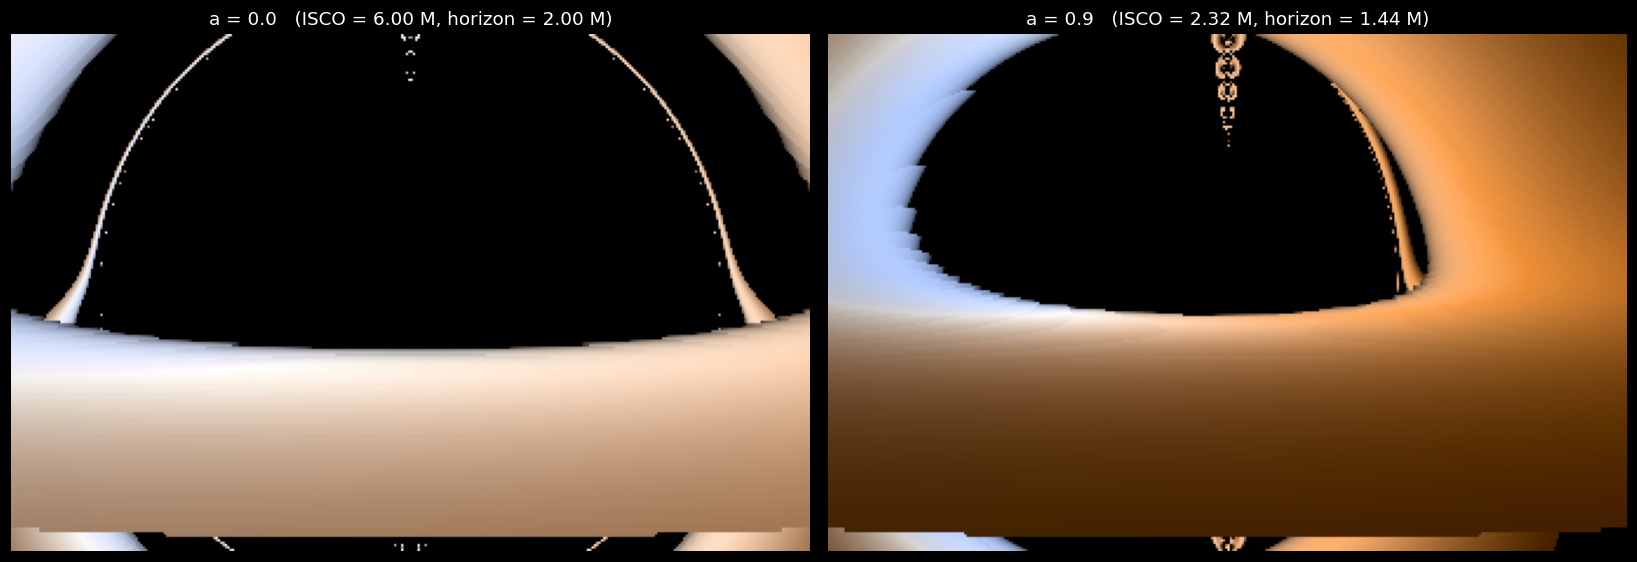

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='black')
for ax, a_s in zip(axes, [0.0, 0.9]):
    r_in = isco_prograde(a_s)
    cam_i, dirs_i = camera_rays(340, 220, incl_deg=82, fov_deg=17)
    h_r, h_L = trace_kerr(cam_i, dirs_i, a_s, r_in, R_OUT)
    im, *_ = shade_kerr(h_r, h_L, a_s, r_in, (220, 340), beaming=False)
    ax.imshow(im, origin='lower'); ax.axis('off')
    ax.set_title(f"a = {a_s}   (ISCO = {r_in:.2f} M, horizon = {horizon(a_s):.2f} M)",
                 color='white')
plt.tight_layout(); plt.show()

left: chapter one's black hole, rendered by chapter two's machinery. right: the same hole using the spinnning things we discussed in this notebook.

the gap between the disk's inner edge and the shadow nearly vanishes when the hole spins. the glowing matter creeps right up to the darkness. 

in the last plot, instead of brightness, let's paint each pixel with its $g$-factor directly. blue means the light arrives blueshifted ($g > 1$), red means redshifted ($g < 1$).

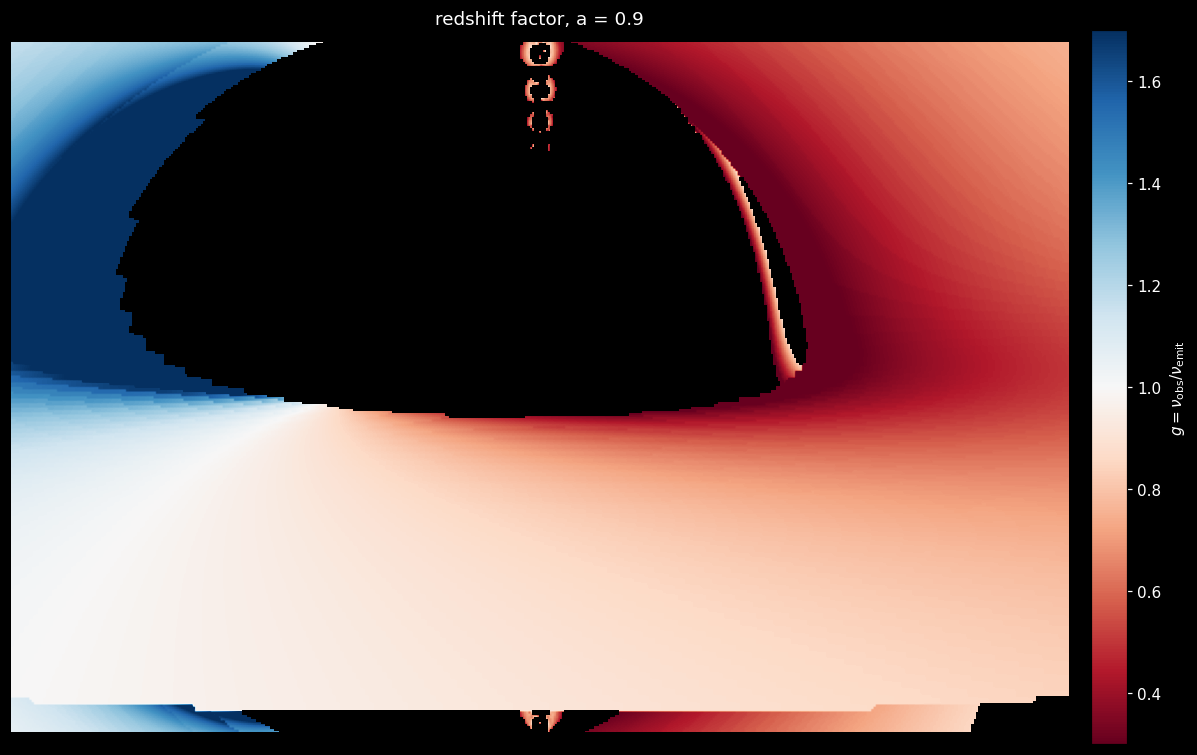

In [9]:
_, g_fac, hit_mask = shade_kerr(hit_r, hit_L, A_SPIN, R_IN, (H_, W), beaming=True)
gmap = np.full(W * H_, np.nan)
gmap[hit_mask] = g_fac
gmap = gmap.reshape(H_, W)

plt.figure(figsize=(11, 7), facecolor='black')
pc = plt.imshow(gmap, origin='lower', cmap='RdBu', vmin=0.3, vmax=1.7)
plt.axis('off')
cb = plt.colorbar(pc, fraction=0.04, pad=0.02)
cb.set_label(r"$g = \nu_{\rm obs}/\nu_{\rm emit}$", color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.get_yticklabels(), color='white')
plt.title(f"redshift factor, a = {A_SPIN}", color='white', pad=12)
plt.tight_layout(); plt.show()

the blueshifted crescent hugs the shadow on the approaching side. for context, that's gas orbiting at a serious fraction of the speed of light, throwing its light forward like a relativistic headlight. everywhere else, gravity's redshift wins.

again, what did we learn?

in chapter one, gravity was chilling. in chapter two, the everything rotates.

we met the kerr metric and its one troublemaking cross term, we let sympy do a week of algebra in under a second, we verified the machine against chapter one before trusting it (always do this), and then we watched frame dragging do three very real things: shrink the horizon, drag the ISCO inward so the disk glows deeper in the well and shove the shadow sideways into the lopsided crescent that the event horizon telescope actually photographs.


some things we haven't touched, for future chapters:
* crank the spin to $a = 0.998$ and watch the ISCO reach $1.24M$
* the ergosphere - the region where standing still is impossible, and where you can, in principle, steal rotational energy from the black hole itself (the penrose process. yes, black holes can be mined. no, i will not be taking questions - mainly because idk either)
* a retrograde disk, orbiting against the spin
* lensed background stars, and an orbiting hot spot flashing multiple images of itself around the shadow

see you in chapter three :3